# Teen mental health EDA — full univariate coverage, age buckets, sleep & screen

Dataset: [algozee/teenager-menthal-healy](https://www.kaggle.com/datasets/algozee/teenager-menthal-healy) (CSV: `Teen_Mental_Health_Dataset.csv`).

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display
from scipy import stats

# --- Light theme: white figure/axes (prints and Kaggle light UI) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#cfd4da",
        "axes.labelcolor": "#24292f",
        "axes.titlecolor": "#24292f",
        "text.color": "#24292f",
        "xtick.color": "#57606a",
        "ytick.color": "#57606a",
        "grid.color": "#e9ecef",
        "grid.linewidth": 0.8,
        "grid.alpha": 1.0,
        "figure.titlesize": 14,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.figsize": (11, 5),
    }
)

CAT_PALETTE = ["#58d5d8", "#a371f7", "#f577a1"]
GENDER_ORDER = ["female", "male"]
GENDER_PALETTE = ["#d62728", "#1f77b4"]  # female red, male blue
SEQ_CMAP = sns.color_palette("mako", as_cmap=True)


def facet_hue_order(series: pd.Series) -> list:
    dtype = series.dtype
    if isinstance(dtype, pd.CategoricalDtype):
        return list(series.cat.categories)
    return sorted(series.unique())


CSV_BASENAME = "Teen_Mental_Health_Dataset.csv"
KAGGLE_SLUG = "algozee/teenager-menthal-healy"
EXPECTED_COLS = [
    "age",
    "gender",
    "daily_social_media_hours",
    "platform_usage",
    "sleep_hours",
    "screen_time_before_sleep",
    "academic_performance",
    "physical_activity",
    "social_interaction_level",
    "stress_level",
    "anxiety_level",
    "addiction_level",
    "depression_label",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "teen" in p.name.lower() and "mental" in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


def bar_counts_pct(
    ax: plt.Axes,
    s: pd.Series,
    title: str,
    order: list[str] | None = None,
    palette: list[str] | None = None,
) -> None:
    vc = s.value_counts()
    if order is not None:
        vc = vc.reindex([x for x in order if x in vc.index])
    if palette is None:
        palette = CAT_PALETTE[: len(vc)]
    bars = ax.bar(vc.index.astype(str), vc.values, color=palette[: len(vc)], edgecolor="#495057", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("count")
    total = int(vc.sum())
    for b in bars:
        h = b.get_height()
        pct = 100.0 * h / total
        ax.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{int(h)}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#24292f",
        )
    ax.tick_params(axis="x", rotation=18)


def chi2_report(name: str, table: pd.DataFrame) -> None:
    chi2, dof, pval, _ = stats.chi2_contingency(table, correction=False)
    print(f"{name}: chi2={chi2:.3f}, dof={dof}, p={pval:.4g}")


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
extra = set(df.columns) - set(EXPECTED_COLS)
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape[0] > 0 and df.shape[1] == len(EXPECTED_COLS)

assert set(df["gender"].unique()) == {"female", "male"}
assert set(df["platform_usage"].unique()) == {"Both", "Instagram", "TikTok"}
assert set(df["social_interaction_level"].unique()) == {"high", "low", "medium"}

social_order = ["low", "medium", "high"]
platform_order = ["Instagram", "TikTok", "Both"]
df["social_interaction_level"] = pd.Categorical(
    df["social_interaction_level"], categories=social_order, ordered=True
)
df["platform_usage"] = pd.Categorical(df["platform_usage"], categories=platform_order)
df["gender"] = pd.Categorical(df["gender"], categories=GENDER_ORDER)

age_levels = sorted(int(x) for x in df["age"].unique())
df["age"] = pd.Categorical(df["age"].astype(int), categories=age_levels, ordered=True)

df["age_bucket"] = pd.cut(
    df["age"].astype(int),
    bins=[11, 14, 16, 18, 22],
    labels=["≤14", "15–16", "17–18", "19+"],
    right=True,
)
assert df["age_bucket"].notna().all(), "unexpected age outside bucket bins"
AGE_BUCKET_ORDER = list(df["age_bucket"].cat.categories)

NUM_DIST_COLS = [
    "daily_social_media_hours",
    "sleep_hours",
    "screen_time_before_sleep",
    "academic_performance",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level",
]

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)
display(df.describe(include="all"))


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV: /Users/nicapotato/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1/Teen_Mental_Health_Dataset.csv
1200 rows × 14 cols


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,age_bucket
459,13,male,4.5,Both,6.7,2.2,3.73,0.3,low,3,5,10,0,≤14
457,16,female,6.3,Instagram,6.9,1.3,2.15,1.4,low,9,2,10,0,15–16
1022,15,male,3.8,TikTok,7.1,0.5,3.08,0.2,medium,2,9,7,0,15–16
141,19,male,2.3,Instagram,6.9,2.3,2.17,1.6,medium,3,6,10,0,19+
668,13,male,7.0,Both,5.7,1.6,3.45,1.2,medium,7,1,10,0,≤14


age                         category
gender                      category
daily_social_media_hours     float64
platform_usage              category
sleep_hours                  float64
screen_time_before_sleep     float64
academic_performance         float64
physical_activity            float64
social_interaction_level    category
stress_level                   int64
anxiety_level                  int64
addiction_level                int64
depression_label               int64
age_bucket                  category
dtype: object

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,age_bucket
count,1200.0,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200
unique,7.0,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,4
top,13.0,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN,≤14
freq,200.0,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN,353
mean,NaN,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833,NaN
std,NaN,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704,NaN
min,NaN,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000,NaN
25%,NaN,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000,NaN
50%,NaN,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000,NaN
75%,NaN,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000,NaN


## 1 — Univariate: every discrete / low-cardinality column

**Columns:** `gender`, `platform_usage`, `social_interaction_level`, integer `age`, `age_bucket`, `depression_label` (0 / 1).


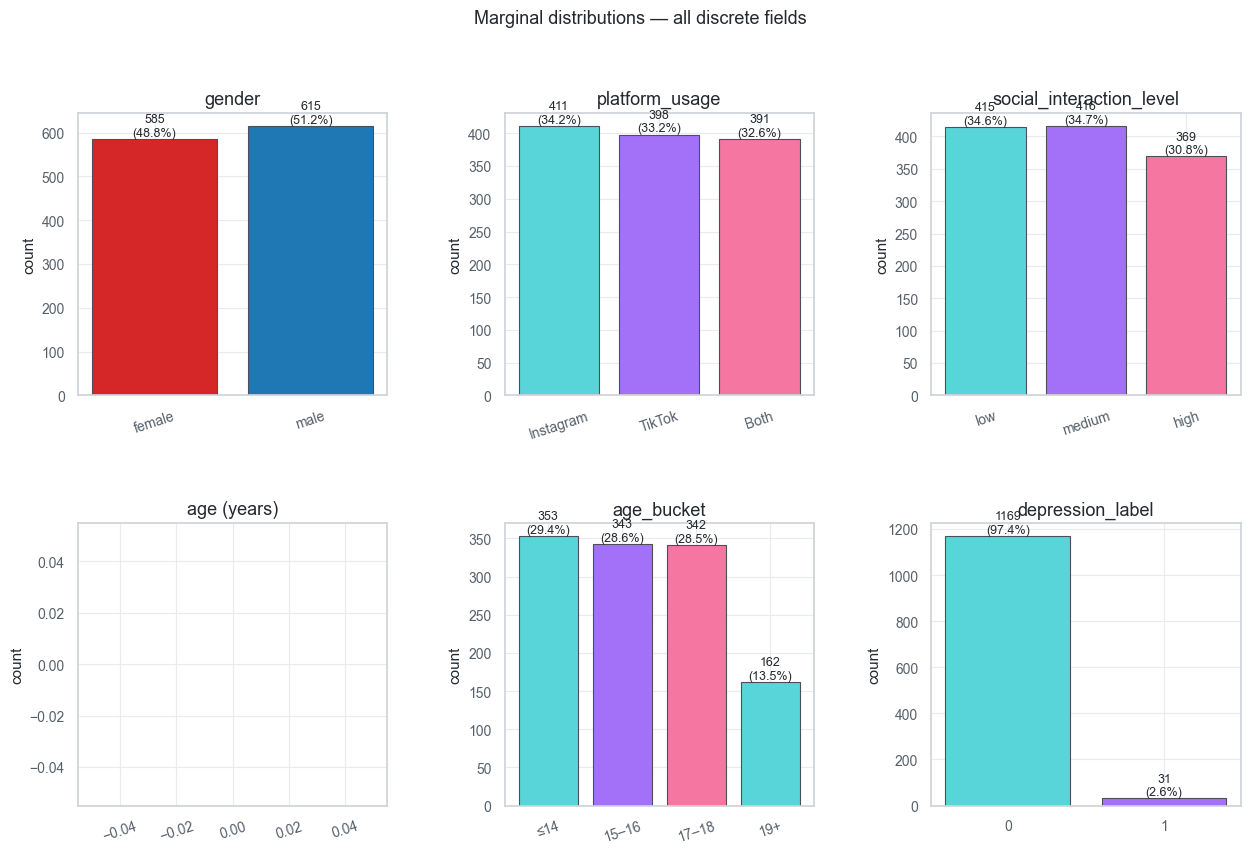

depression_label counts:
 depression_label
0    1169
1      31
Name: count, dtype: int64


In [2]:
sns.set_palette(CAT_PALETTE)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plt.subplots_adjust(wspace=0.38, hspace=0.45)

bar_counts_pct(axes[0, 0], df["gender"], "gender", order=GENDER_ORDER, palette=GENDER_PALETTE)
bar_counts_pct(axes[0, 1], df["platform_usage"], "platform_usage", order=platform_order)

bar_counts_pct(
    axes[0, 2],
    df["social_interaction_level"],
    "social_interaction_level",
    order=social_order,
)

bar_counts_pct(
    axes[1, 0],
    df["age"],
    "age (years)",
    order=[str(x) for x in age_levels],
)

bar_counts_pct(
    axes[1, 1],
    df["age_bucket"].astype(str),
    "age_bucket",
    order=[str(x) for x in AGE_BUCKET_ORDER],
)

dc = df["depression_label"].value_counts().sort_index()
palette_dep = CAT_PALETTE[: len(dc)]
bax = axes[1, 2]
bars = bax.bar(dc.index.astype(str), dc.values, color=palette_dep, edgecolor="#495057", linewidth=0.8)
bax.set_title("depression_label")
bax.set_ylabel("count")
tdep = int(dc.sum())
for b in bars:
    h = b.get_height()
    pct = 100.0 * h / tdep
    bax.text(
        b.get_x() + b.get_width() / 2,
        h,
        f"{int(h)}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#24292f",
    )

plt.suptitle("Marginal distributions — all discrete fields", y=0.995, fontsize=13)
plt.show()

print("depression_label counts:\n", df["depression_label"].value_counts().sort_index())


## 2 — Univariate: every continuous-scale numeric column

Histogram + KDE for hours, performance, activity, and integer scales. These show **typical ranges** before conditioning.


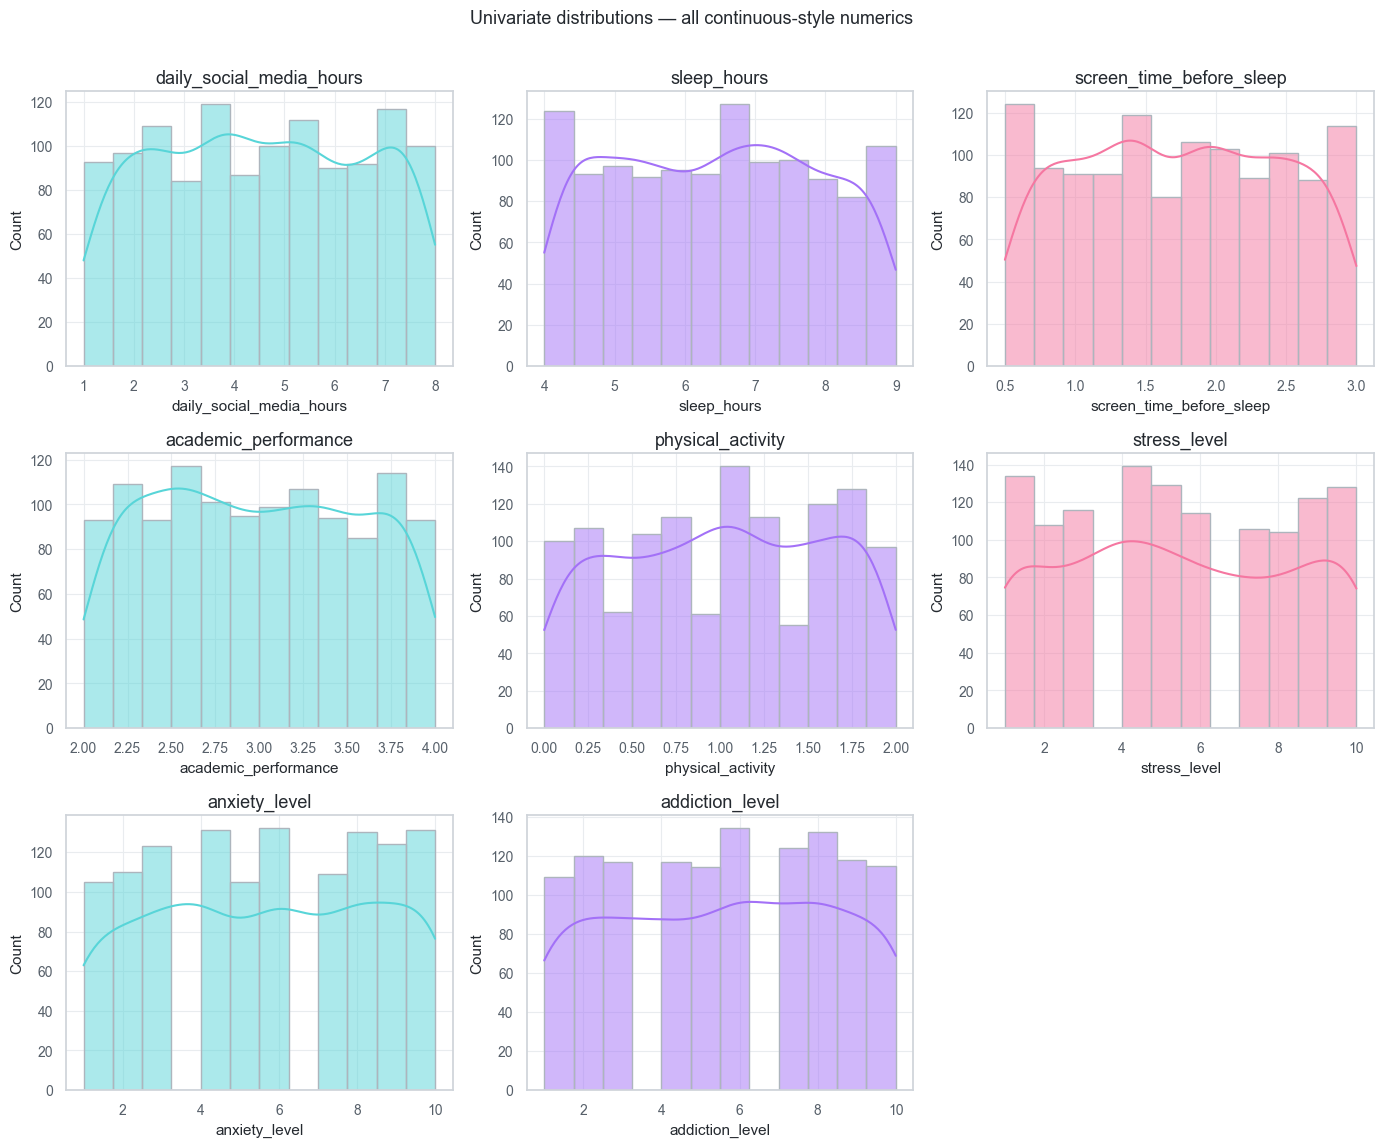

In [3]:
n = len(NUM_DIST_COLS)
nrow = int(np.ceil(n / 3))
fig, axes = plt.subplots(nrow, 3, figsize=(14, 3.8 * nrow))
axes = np.atleast_2d(axes)
for i, col in enumerate(NUM_DIST_COLS):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    sns.histplot(df[col], kde=True, ax=ax, color=CAT_PALETTE[i % len(CAT_PALETTE)], edgecolor="#adb5bd")
    ax.set_title(col)
for j in range(i + 1, nrow * 3):
    r, c = divmod(j, 3)
    axes[r, c].axis("off")

plt.suptitle("Univariate distributions — all continuous-style numerics", y=1.005, fontsize=13)
plt.tight_layout()
plt.show()

display(df[NUM_DIST_COLS].describe())


## 3 — Mental health indicators by age bucket

Mean **stress**, **anxiety**, **addiction** and depression **prevalence** (`depression_label == 1`) by `age_bucket`.


,n,stress_mean,anxiety_mean,addiction_mean,depression_rate
age_bucket,,,,,
≤14,353,5.771,5.459,5.510,0.020
15–16,343,5.286,5.787,5.344,0.035
17–18,342,5.187,5.497,5.681,0.018
19+,162,5.623,6.000,5.907,0.037


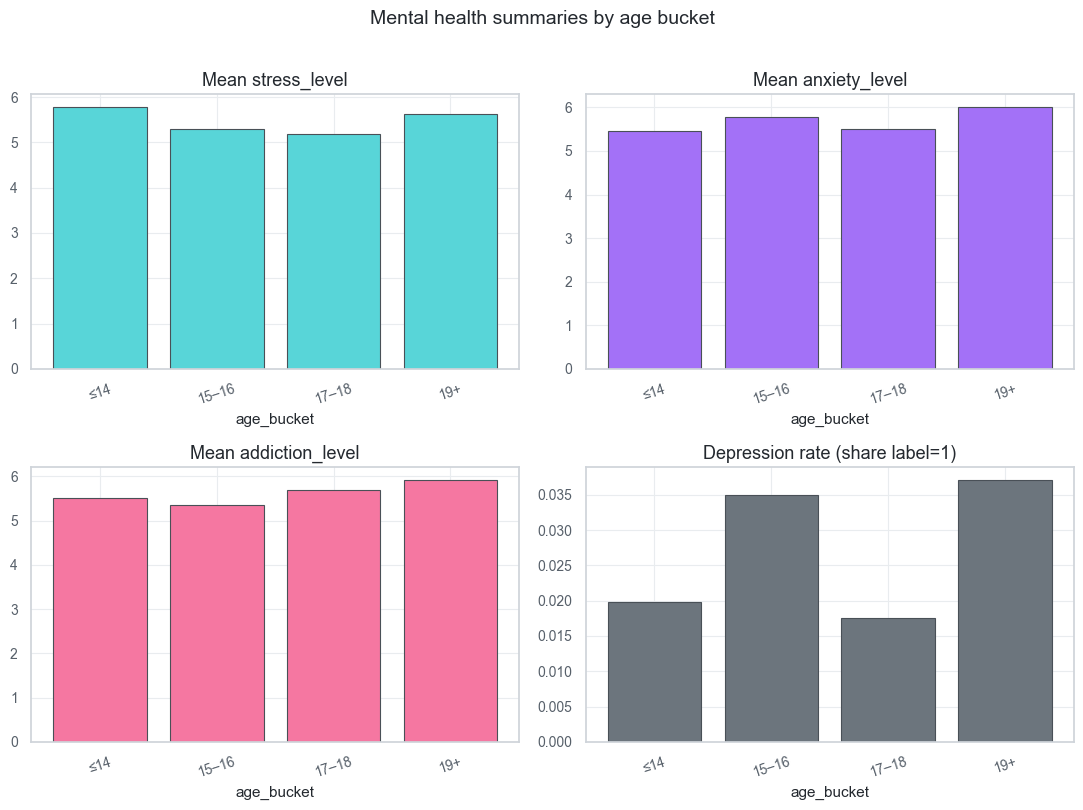

Kruskal–Wallis stress across age buckets: p= 0.03156680697085171
Kruskal–Wallis anxiety: 0.13497351287358464
Kruskal–Wallis addiction: 0.15932103244325443
depression × age_bucket (counts): chi2=3.389, dof=0.3354472174263876, p=3


In [4]:
aged = (
    df.groupby("age_bucket", observed=True)
    .agg(
        n=("stress_level", "count"),
        stress_mean=("stress_level", "mean"),
        anxiety_mean=("anxiety_level", "mean"),
        addiction_mean=("addiction_level", "mean"),
        depression_rate=("depression_label", "mean"),
    )
    .reindex(AGE_BUCKET_ORDER)
)
display(aged.round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
metrics = [
    ("stress_mean", "Mean stress_level", "#58d5d8"),
    ("anxiety_mean", "Mean anxiety_level", "#a371f7"),
    ("addiction_mean", "Mean addiction_level", "#f577a1"),
    ("depression_rate", "Depression rate (share label=1)", "#6c757d"),
]
for ax, (mc, ttl, clr) in zip(axes.ravel(), metrics):
    ys = aged[mc].astype(float)
    xs = np.arange(len(ys))
    ax.bar(xs, ys, color=clr, edgecolor="#495057", linewidth=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(i) for i in aged.index], rotation=18)
    ax.set_title(ttl)
    ax.set_xlabel("age_bucket")
plt.suptitle("Mental health summaries by age bucket", y=1.01)
plt.tight_layout()
plt.show()

gb = [g["stress_level"].values for _, g in df.groupby("age_bucket", observed=True)]
print(
    "Kruskal–Wallis stress across age buckets: p=",
    stats.kruskal(*gb).pvalue,
)
gb = [g["anxiety_level"].values for _, g in df.groupby("age_bucket", observed=True)]
print("Kruskal–Wallis anxiety:", stats.kruskal(*gb).pvalue)
gb = [g["addiction_level"].values for _, g in df.groupby("age_bucket", observed=True)]
print("Kruskal–Wallis addiction:", stats.kruskal(*gb).pvalue)
chi2_report(
    "depression × age_bucket (counts)",
    pd.crosstab(df["depression_label"], df["age_bucket"]),
)


## 4 — Sleep hours & screen time before sleep

**Univariate** shapes for both fields are in section **2**. Here: **association** (correlation + joint KDE) and mean pre-sleep screen by sleep quartile.


Pearson r=0.0102, p=0.7232
Spearman rho=0.0099, p=0.7325


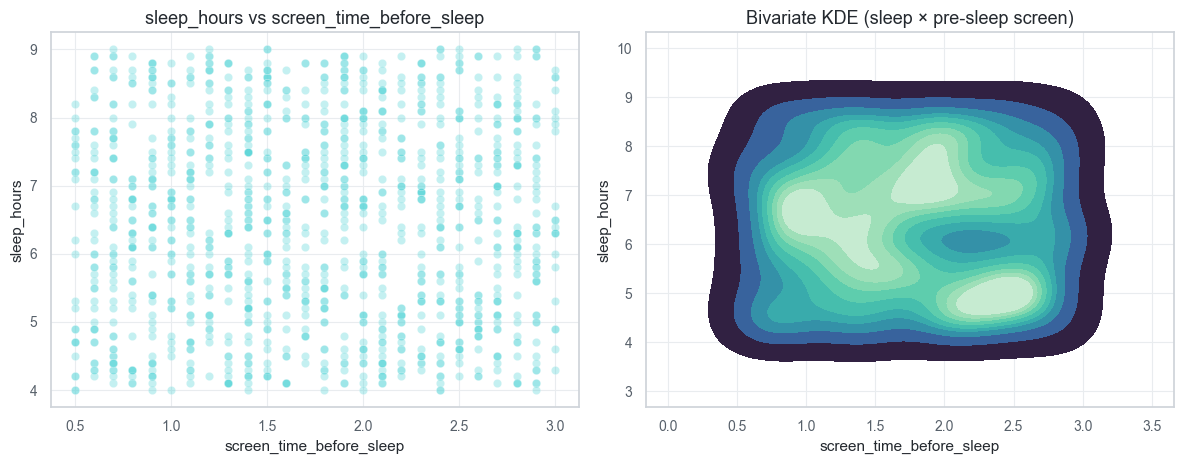

screen_time_before_sleep by sleep_hours quartile:


,mean,median,count
sleep_quartile,,,
"(3.999, 5.2]",1.747,1.8,314
"(5.2, 6.5]",1.737,1.6,304
"(6.5, 7.6]",1.716,1.8,284
"(7.6, 9.0]",1.760,1.8,298


In [5]:
pear_r, pear_p = stats.pearsonr(df["sleep_hours"], df["screen_time_before_sleep"])
spear_r, spear_p = stats.spearmanr(df["sleep_hours"], df["screen_time_before_sleep"])
print(f"Pearson r={pear_r:.4f}, p={pear_p:.4g}")
print(f"Spearman rho={spear_r:.4f}, p={spear_p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.scatterplot(
    data=df,
    x="screen_time_before_sleep",
    y="sleep_hours",
    alpha=0.35,
    ax=axes[0],
    color=CAT_PALETTE[0],
)
axes[0].set_title("sleep_hours vs screen_time_before_sleep")

sns.kdeplot(
    data=df, x="screen_time_before_sleep", y="sleep_hours", fill=True, cmap="mako", ax=axes[1]
)
axes[1].set_title("Bivariate KDE (sleep × pre-sleep screen)")
plt.tight_layout()
plt.show()

sleep_q = pd.qcut(df["sleep_hours"], q=4, duplicates="drop")
tmp = (
    df.assign(sleep_quartile=sleep_q)
    .groupby("sleep_quartile", observed=True)["screen_time_before_sleep"]
    .agg(["mean", "median", "count"])
)
print("screen_time_before_sleep by sleep_hours quartile:")
display(tmp.round(3))


## 5 — PairGrid & JointGrid: all numerics stratified by demographics

**PairGrid** follows the stacked-step histograms on the diagonal and **scatter** off-diagonal (penguin-style), with **hue** rotating across `gender`, `platform_usage`, `social_interaction_level`, and `age_bucket`.

**JointGrid** highlights two outcome-relevant pairs (`sleep_hours` × `screen_time_before_sleep`, `stress_level` × `anxiety_level`) with the same hue breakdown. `corner=True` keeps the pairwise matrix to the lower triangle + diagonal for readability with eight numeric fields.


## 6 — Categorical × categorical: crosstabs, heatmaps, chi-square

Heatmaps show **counts** then **row shares** within the first dimension. $\chi^2$ tests independence.


Gender x platform: chi2=0.105, dof=0.948888983759524, p=2


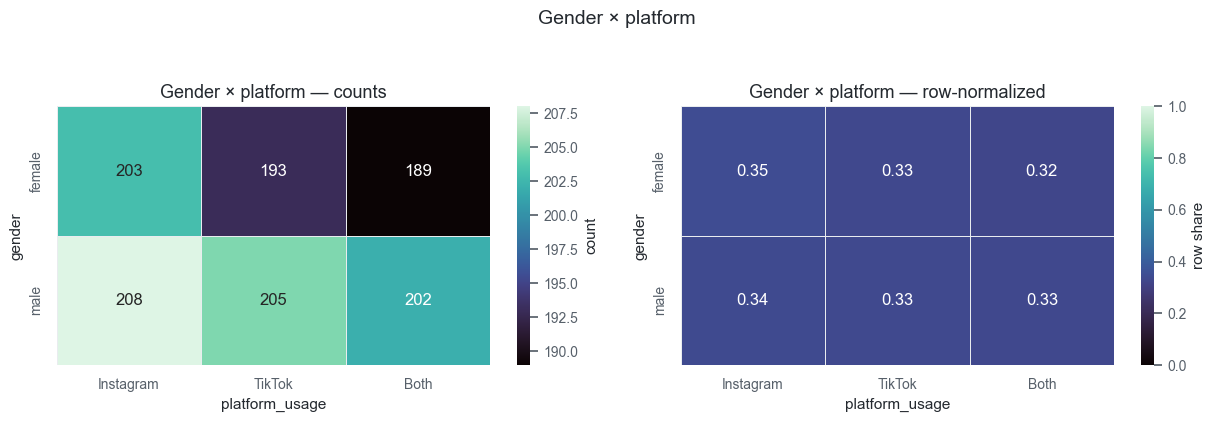

Gender x social interaction: chi2=2.299, dof=0.31673913445835905, p=2


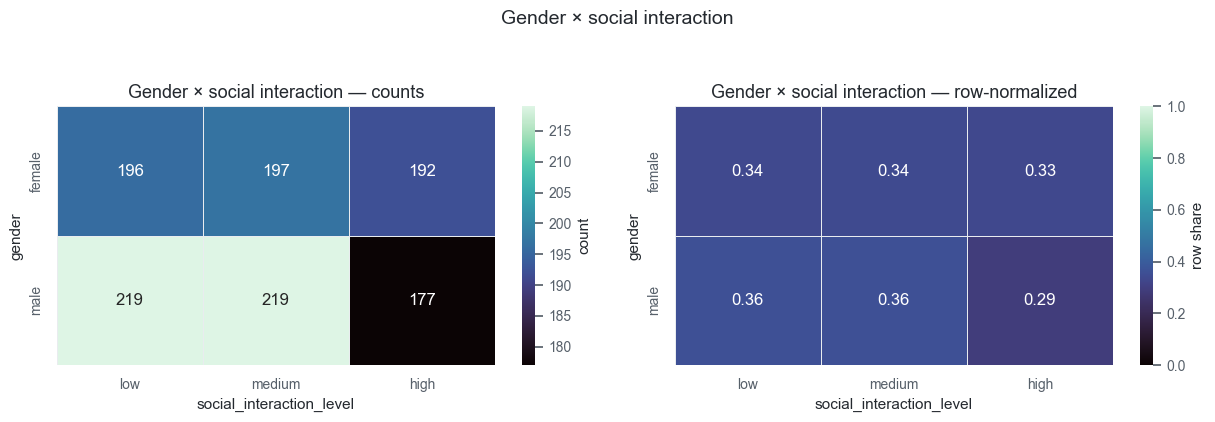

Platform x social interaction: chi2=13.805, dof=0.007942911266326432, p=4


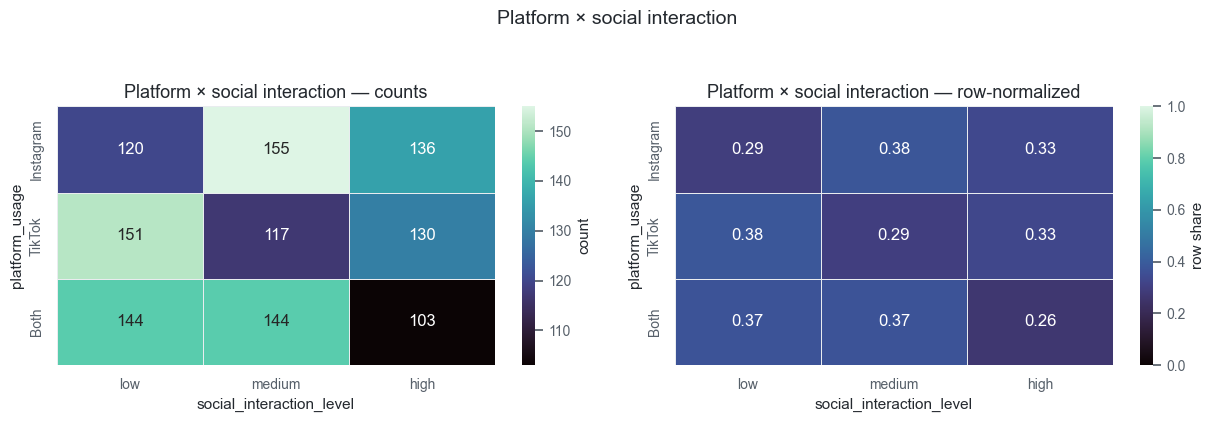

In [7]:
pairs = [
    ("gender", "platform_usage", "Gender × platform"),
    ("gender", "social_interaction_level", "Gender × social interaction"),
    ("platform_usage", "social_interaction_level", "Platform × social interaction"),
]

for dim_a, dim_b, title in pairs:
    ct = pd.crosstab(df[dim_a], df[dim_b])
    pct_row = ct.div(ct.sum(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
    sns.heatmap(
        ct,
        annot=True,
        fmt="d",
        cmap=SEQ_CMAP,
        linewidths=0.5,
        linecolor="#e9ecef",
        ax=axes[0],
        cbar_kws={"label": "count"},
    )
    axes[0].set_title(f"{title} — counts")

    sns.heatmap(
        pct_row,
        annot=True,
        fmt=".2f",
        cmap=SEQ_CMAP,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="#e9ecef",
        ax=axes[1],
        cbar_kws={"label": "row share"},
    )
    axes[1].set_title(f"{title} — row-normalized")

    chi2_report(title.replace(" × ", " x "), ct)
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


## 7 — Categorical × numerical (stress & sleep)


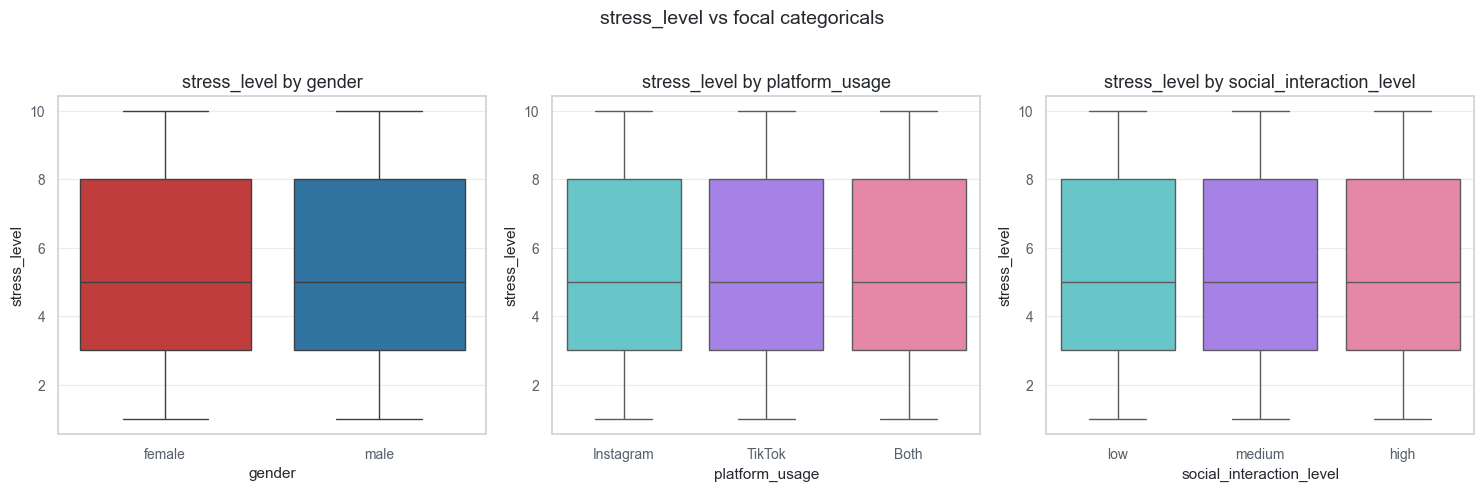

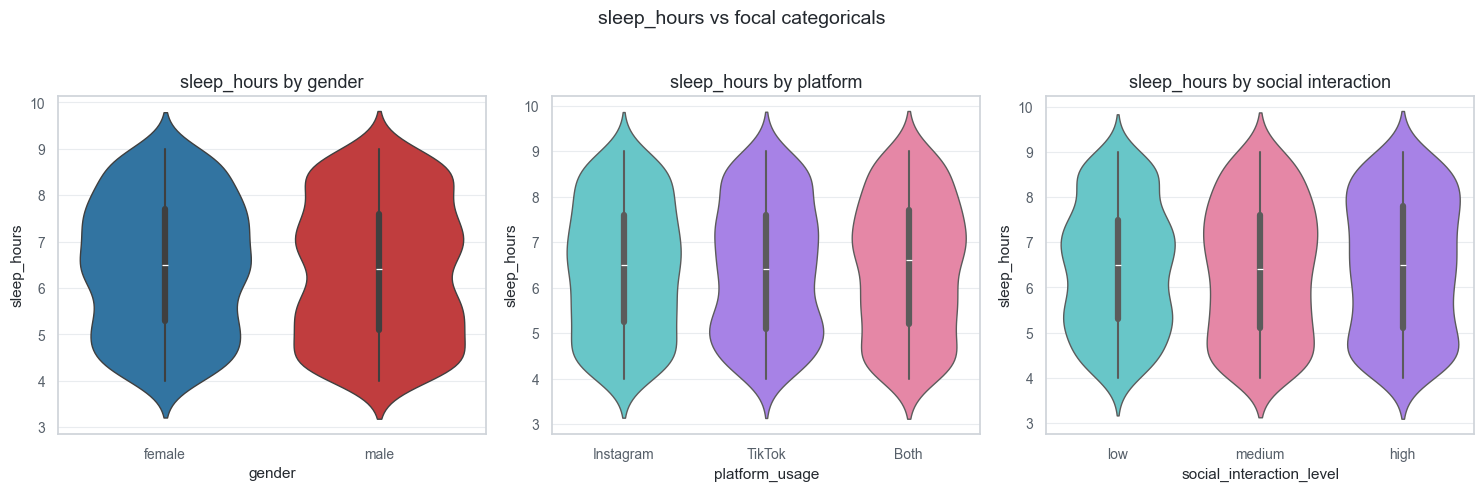

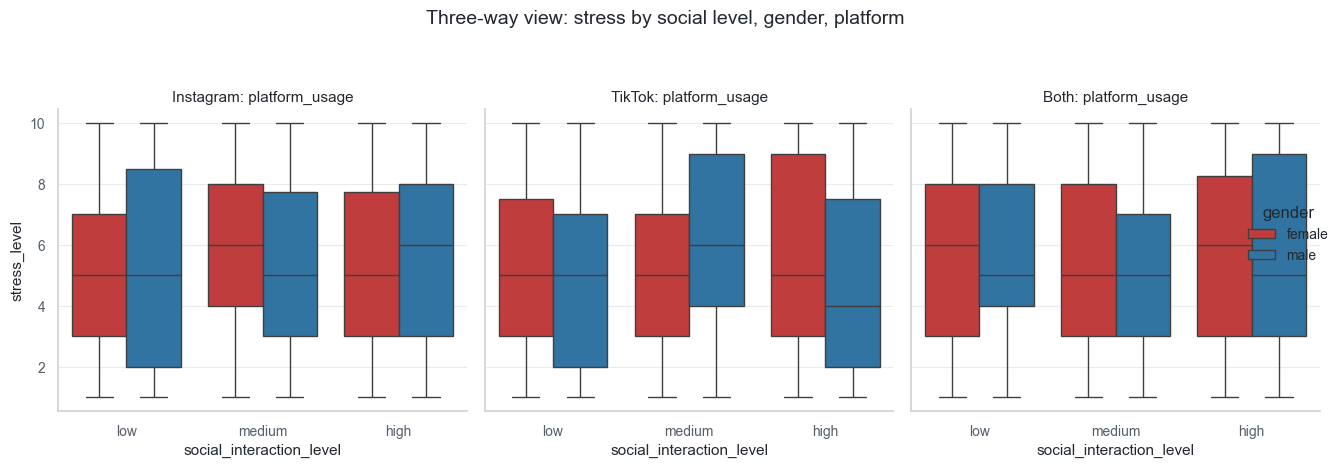

In [8]:
stress_metrics = ["stress_level"]

for metric in stress_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    for ax, facet, ttl in zip(
        axes,
        ["gender", "platform_usage", "social_interaction_level"],
        ["by gender", "by platform_usage", "by social_interaction_level"],
    ):
        xs = df[facet]
        hue_order = facet_hue_order(xs)
        pal = GENDER_PALETTE if facet == "gender" else CAT_PALETTE[: len(hue_order)]
        sns.boxplot(
            data=df,
            x=facet,
            y=metric,
            ax=ax,
            order=hue_order,
            hue=facet,
            hue_order=hue_order,
            palette=pal,
            dodge=False,
            legend=False,
            linewidth=1,
        )
        ax.set_title(f"{metric} {ttl}")
    plt.suptitle(f"{metric} vs focal categoricals", y=1.02)
    plt.tight_layout()
    plt.show()

for metric in ["sleep_hours"]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    for ax, facet, ttl in zip(
        axes,
        ["gender", "platform_usage", "social_interaction_level"],
        ["by gender", "by platform", "by social interaction"],
    ):
        xs = df[facet]
        hue_order = facet_hue_order(xs)
        pal = GENDER_PALETTE if facet == "gender" else CAT_PALETTE[: len(hue_order)]
        sns.violinplot(
            data=df,
            x=facet,
            y=metric,
            ax=ax,
            order=hue_order,
            hue=facet,
            hue_order=hue_order,
            palette=pal,
            dodge=False,
            legend=False,
            linewidth=1,
            inner="box",
        )
        ax.set_title(f"{metric} {ttl}")
    plt.suptitle(f"{metric} vs focal categoricals", y=1.02)
    plt.tight_layout()
    plt.show()

g = sns.catplot(
    data=df,
    kind="box",
    x="social_interaction_level",
    y="stress_level",
    hue="gender",
    hue_order=GENDER_ORDER,
    col="platform_usage",
    height=4.4,
    aspect=0.95,
    palette=GENDER_PALETTE,
    linewidth=1,
)
g.set_axis_labels("social_interaction_level", "stress_level")
g.set_titles("{col_name}: {col_var}")
plt.suptitle("Three-way view: stress by social level, gender, platform", y=1.06)
plt.tight_layout()
plt.show()


## Synthesis (patterns, not causes)

**Agent-readable bullets:**

1. **Univariate completeness** — Section 1: every discrete column (including `age`, `age_bucket`, `depression_label`). Section 2: every continuous-style numeric in `NUM_DIST_COLS`.
2. **Age buckets (§3)** — Table + bars for mean stress/anxiety/addiction and depression rate; Kruskal–Wallis / $\chi^2$ are omnibus checks, not causal claims.
3. **Sleep & screen (§4)** — Correlation + KDE describe how the two co-vary; quartile table links shorter sleep to pre-sleep screen **on average**.

4. **PairGrid / JointGrid (§5)** — Full numeric co-structure with hue by gender, platform, social level, and age bucket; joint plots stress two key bivariate slices (sleep vs pre-sleep screen; stress vs anxiety).
5. **Crosstabs (§6)** — Row shares vs raw counts for composition.
6. **Demographics × outcomes (§7)** — Box/violin and faceted stress by platform × gender × social level.
7. **Rare depression class** — Stratify carefully (~31 positives in full sample).
